In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.shape

(4238, 16)

In [6]:
import matplotlib.pyplot as plt

{'whiskers': [<matplotlib.lines.Line2D at 0x1d621ec7390>,
 'caps': [<matplotlib.lines.Line2D at 0x1d621ec7610>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d621dbf110>],
 'medians': [<matplotlib.lines.Line2D at 0x1d621ec7750>],
 'fliers': [<matplotlib.lines.Line2D at 0x1d621ec7890>],
 'means': []}

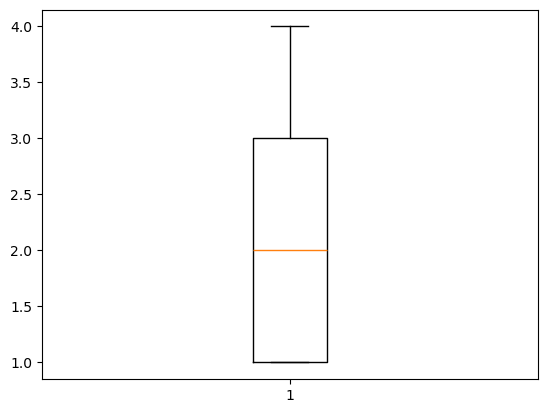

In [7]:
plt.boxplot(df["education"].dropna())

In [8]:
df.education = df["education"].fillna(df.education.median())

In [9]:
df.education.isna().sum()

np.int64(0)

In [10]:
df.cigsPerDay.isna().sum()

np.int64(29)

In [11]:
df.cigsPerDay.describe()

count    4209.000000
mean        9.003089
std        11.920094
min         0.000000
25%         0.000000
50%         0.000000
75%        20.000000
max        70.000000
Name: cigsPerDay, dtype: float64

In [12]:
df.cigsPerDay = df.cigsPerDay.fillna(df.cigsPerDay.median())

In [13]:
df.cigsPerDay.isna().sum()

np.int64(0)

In [14]:
missing_cols = ['BPMeds', 'totChol', 'BMI', 'heartRate', 'glucose']

In [15]:
for col in missing_cols:
    df[col] = df[col].fillna(df[col].median())

In [16]:
df['TenYearCHD'].value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

In [17]:
print(df['TenYearCHD'].value_counts(normalize=True) * 100)

TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [19]:
X = df.drop(columns=['TenYearCHD'])
y = df['TenYearCHD']

In [20]:
X

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0


In [21]:
y

0       0
1       0
2       0
3       1
4       0
       ..
4233    1
4234    0
4235    0
4236    0
4237    0
Name: TenYearCHD, Length: 4238, dtype: int64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [24]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [31]:
X_train.shape

(2839, 15)

In [32]:
X_train_res, y_train_res = smote.fit_resample(X_train_sm, y_train)

In [33]:
X_train_sm

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,48,2.000000,1,60.000000,0.000000,0,0,0,232.000000,136.000000,81.000000,25.830000,80.000000,78.000000
1,1,62,1.000000,0,0.000000,0.000000,0,0,0,157.000000,130.000000,87.000000,28.730000,72.000000,47.000000
2,0,54,3.000000,0,0.000000,0.000000,0,0,0,278.000000,127.500000,83.000000,23.080000,63.000000,78.000000
3,1,42,1.000000,0,0.000000,0.000000,0,0,0,242.000000,121.000000,80.000000,27.830000,72.000000,78.000000
4,0,65,1.000000,0,0.000000,1.000000,0,1,0,342.000000,168.500000,98.500000,23.870000,75.000000,60.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,0,47,1.276504,0,0.000000,0.907832,0,1,0,276.354824,139.790351,99.829512,38.391124,85.460840,81.645176
4796,1,42,1.000000,1,20.000000,0.000000,0,0,0,230.265706,105.904451,74.734294,22.141401,66.755235,79.925392
4797,0,54,2.547449,1,18.868624,0.000000,0,0,0,328.167854,154.908807,93.766458,23.585546,83.868624,85.773725
4798,0,61,1.000000,0,0.000000,0.000000,0,1,0,200.269886,165.699473,93.865057,28.299489,76.956980,94.374188


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

In [36]:
results = []

In [53]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train_sm)
    y_pred_train = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred_train)
    prec = precision_score(y_test, y_pred_train)
    rec = recall_score(y_test, y_pred_train)
    f1 = f1_score(y_test, y_pred_train)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred_train))
    print("-" * 50)

import pandas as pd
results_df = pd.DataFrame(results)
print("\n=== Model Comparison Table ===")
print(results_df)

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.89      0.69      0.78      1194
           1       0.22      0.51      0.30       205

    accuracy                           0.66      1399
   macro avg       0.55      0.60      0.54      1399
weighted avg       0.79      0.66      0.71      1399

--------------------------------------------------
=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1194
           1       0.23      0.34      0.28       205

    accuracy                           0.74      1399
   macro avg       0.55      0.57      0.56      1399
weighted avg       0.78      0.74      0.76      1399

--------------------------------------------------
=== Random Forest ===
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1194
           1       0.30      0.16      0.21       205

    accu

In [55]:
from sklearn.model_selection import GridSearchCV

In [56]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

In [57]:
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1)

In [58]:
grid_search.fit(X_train_scaled, y_train_sm)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced', None], 'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [59]:
best_rf = grid_search.best_estimator_

In [60]:
y_pred_tuned = best_rf.predict(X_test_scaled)

In [61]:
print("=== Best Hyperparameters ===")
print(grid_search.best_params_)

print("\n=== Tuned Model Performance ===")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%")
print(f"Final Test Recall:   {recall_score(y_test, y_pred_tuned) * 100:.2f}%")
print(f"Final Test F1-Score: {f1_score(y_test, y_pred_tuned) * 100:.2f}%")

print("\n=== Tuned Classification Report ===")
print(classification_report(y_test, y_pred_tuned))

=== Best Hyperparameters ===
{'class_weight': 'balanced', 'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}

=== Tuned Model Performance ===
Final Test Accuracy: 81.77%
Final Test Recall:   20.00%
Final Test F1-Score: 24.33%

=== Tuned Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.92      0.90      1194
           1       0.31      0.20      0.24       205

    accuracy                           0.82      1399
   macro avg       0.59      0.56      0.57      1399
weighted avg       0.79      0.82      0.80      1399

